**SECTION 1 — IMPORT LIBRARIES**

In [1]:
# Core
import pandas as pd
import numpy as np
import re

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier

# NLP
from transformers import pipeline

# Shap Explainability
import shap

# Install XGBoost
!pip install xgboost

# Sentiment distribution
!pip install textblob
from textblob import TextBlob

# Install if needed
!pip install nbconvert

**SECTION 2 — LOAD SOCIAL MEDIA DATA**

In [2]:
def load_csv(file):
    try:
        return pd.read_csv(file, encoding="utf-8")
    except:
        return pd.read_csv(file, encoding="latin1")

fb1 = load_csv("/content/facebook1.csv")
fb2 = load_csv("/content/facebook2.csv")
yt1 = load_csv("/content/youtube1.csv")
yt2 = load_csv("/content/youtube2.csv")
tk = load_csv("/content/tiktok.csv")
survey = load_csv("/content/social_media_votes.csv")

**SECTION 3 — DATA PREPROCESSING & COLUMN STANDARDIZATION**

3.1 Data Integration

In [3]:
print("FB1:", fb1.shape)
print("FB2:", fb2.shape)
print("YT1:", yt1.shape)
print("YT2:", yt2.shape)
print("TikTok:", tk.shape)

FB1: (207, 33)
FB2: (429, 48)
YT1: (55, 29)
YT2: (162, 27)
TikTok: (72, 8)


3.2 Column Standardisation

In [4]:
def standardize(df, platform, year):
    df.columns = df.columns.str.lower().str.strip()

    # Create required columns if missing
    required_cols = ["text", "likes", "comments", "shares", "views"]

    for col in required_cols:
        if col not in df.columns:
            df[col] = 0

    # Convert numeric safely
    for col in ["likes", "comments", "shares", "views"]:
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

    # Combine text fields
    text_cols = [c for c in df.columns if "text" in c or "caption" in c or "title" in c]
    df["text"] = df[text_cols].astype(str).agg(" ".join, axis=1)

    df["platform"] = platform
    df["year"] = year

    return df

fb1 = standardize(fb1, "Facebook", 2019)
fb2 = standardize(fb2, "Facebook", 2024)
yt1 = standardize(yt1, "YouTube", 2019)
yt2 = standardize(yt2, "YouTube", 2024)
tk = standardize(tk, "TikTok", 2024)

3.3 Master Dataset

In [5]:
data = pd.concat([fb1, fb2, yt1, yt2, tk], ignore_index=True)

print("TOTAL RECORDS:", data.shape)

print(data["platform"].value_counts())

TOTAL RECORDS: (925, 102)
platform
Facebook    636
YouTube     217
TikTok       72
Name: count, dtype: int64


3.4 Feature Engineering

In [6]:
def compute_engagement(row):
    if row["platform"] == "TikTok":
        return row["likes"] + row["comments"] + row["shares"]

    elif row["platform"] == "YouTube":
        return row["views"]

    elif row["platform"] == "Facebook":
        return 1  # presence-based

    return 0

data["engagement"] = (
    data["likes"] +
    data["comments"] +
    data["shares"]
)

data["text_length"] = data["text"].apply(len)

3.5 Sentiment Analysis

In [7]:
from textblob import TextBlob

data["sentiment_score"] = data["text"].apply(
    lambda x: TextBlob(str(x)).sentiment.polarity
)

data["sentiment_category"] = data["sentiment_score"].apply(
    lambda x: "Positive" if x > 0 else ("Negative" if x < 0 else "Neutral")
)

3.6 Data Validation

In [8]:
# Re-create analysis_data
analysis_data = pd.concat([fb1, fb2, yt1, yt2, tk], ignore_index=True).assign(engagement=lambda x: x.get("engagement", 0))

# Now run your line
print(analysis_data["engagement"].describe())

count    925.0
mean       0.0
std        0.0
min        0.0
25%        0.0
50%        0.0
75%        0.0
max        0.0
Name: engagement, dtype: float64


3.7 No Data Loss Check

In [9]:
print("Missing text:", data["text"].isnull().sum())
print("Missing engagement:", data["engagement"].isnull().sum())

Missing text: 0
Missing engagement: 0


**SECTION 4 - TRAIN TEST DATA**

4.1 Feature Selection

In [10]:
# Clean column names
survey.columns = (
    survey.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

# Define target
y = survey["firstvote"]

# Define features
X = survey[[
    "secondvote",
    "policyinclination",
    "isexecutivepresidencyrequired",
    "voteof2015",
    "age",
    "gender",
    "religion",
    "income",
    "ethnicity",
    "district",
    "education"
]]

4.2 Encoding Categorical Variables

In [11]:
# Convert categorical data to numeric
X = pd.get_dummies(X)

# Encode target
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)

print("Feature shape:", X.shape)

Feature shape: (43, 59)


4.3 Train-Test Split

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

4.4 SHAP Explainability

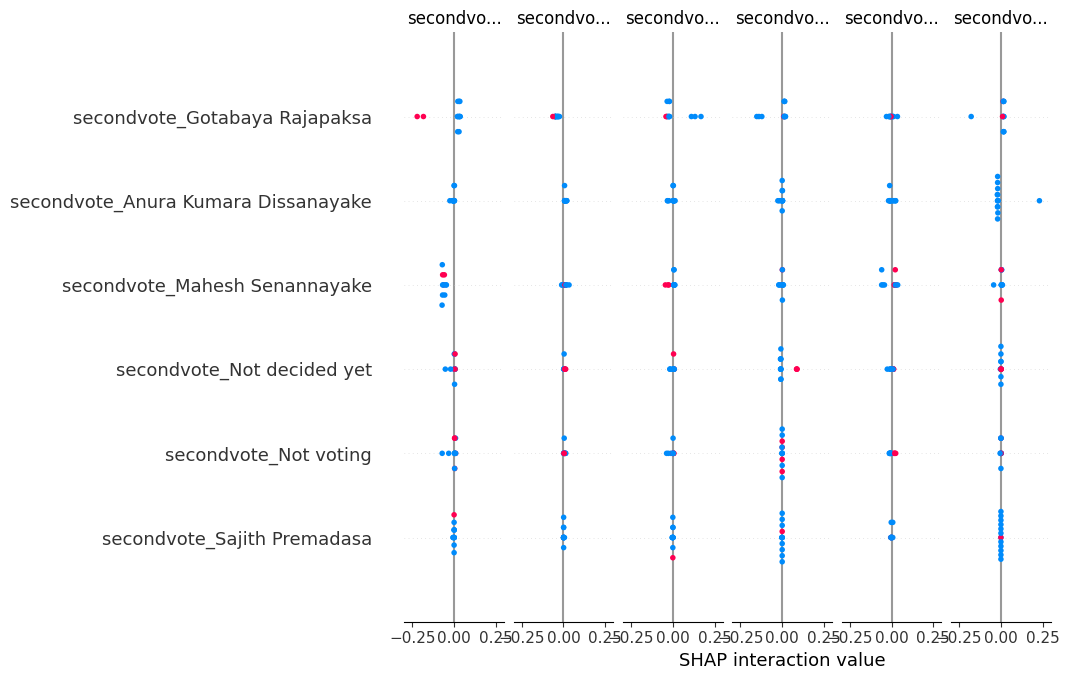

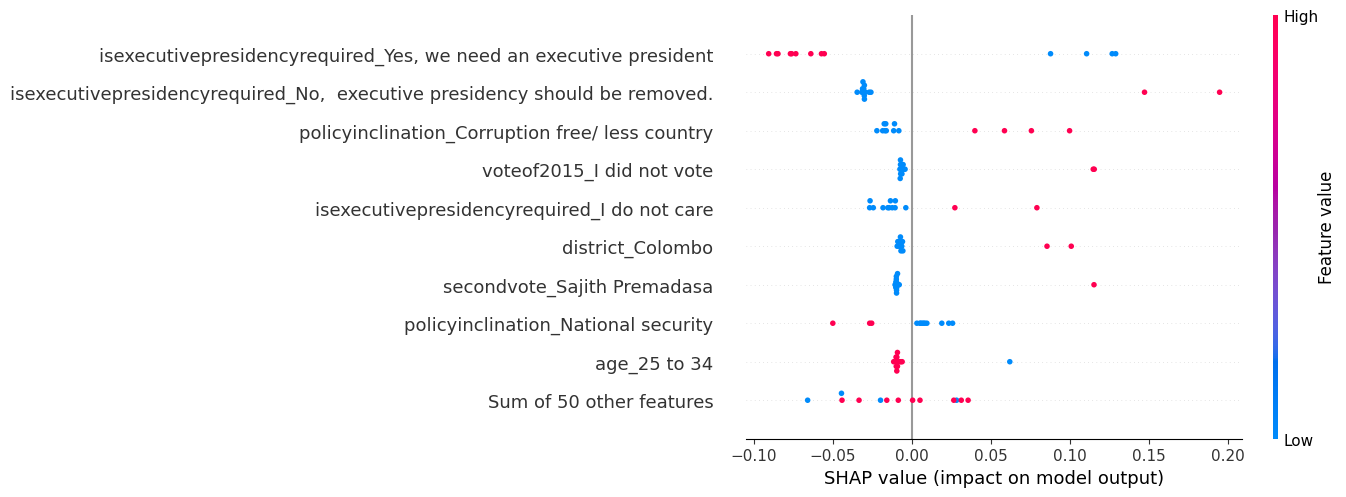


SHAP Explanation for Class 0


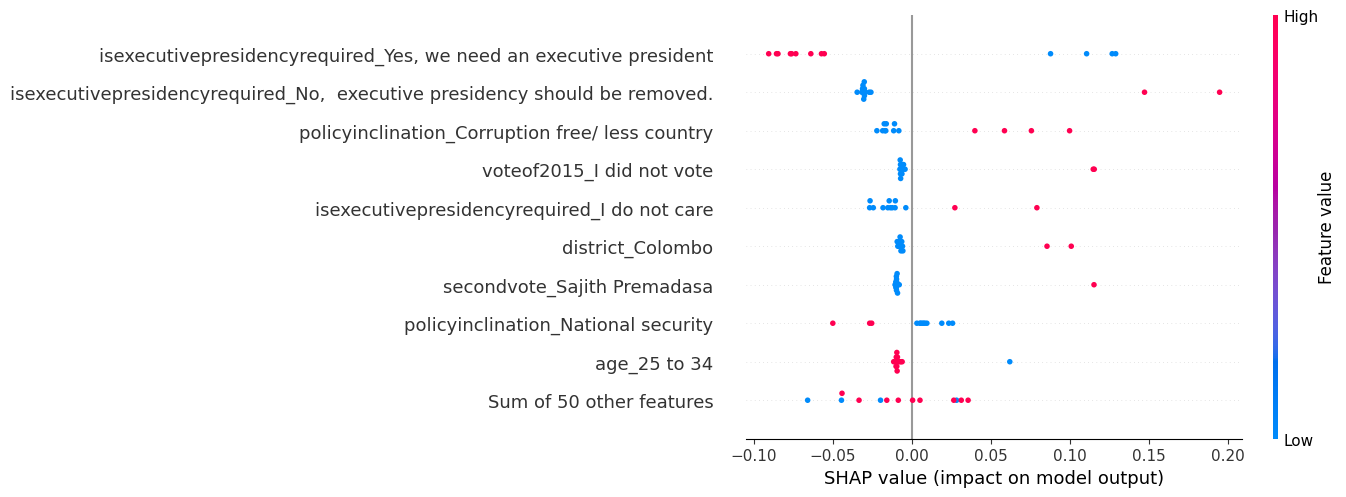


SHAP Explanation for Class 1


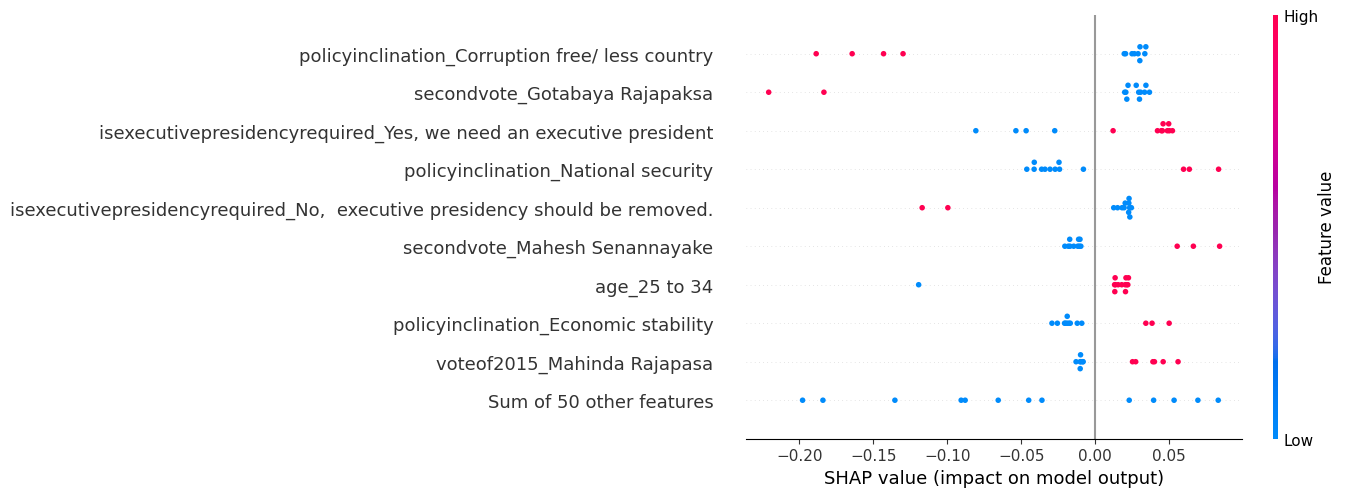


SHAP Explanation for Class 2


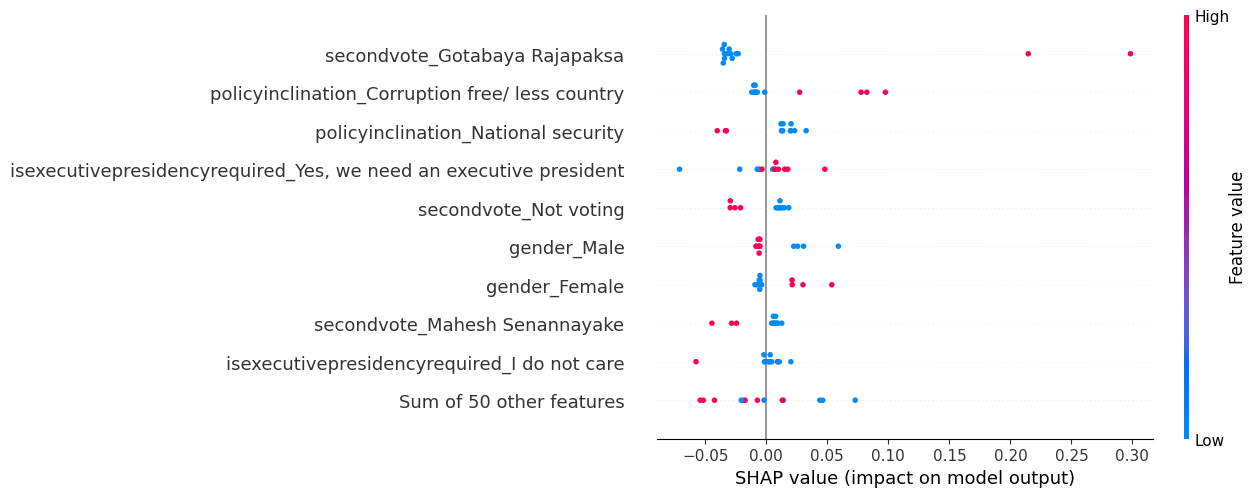


SHAP Explanation for Class 3


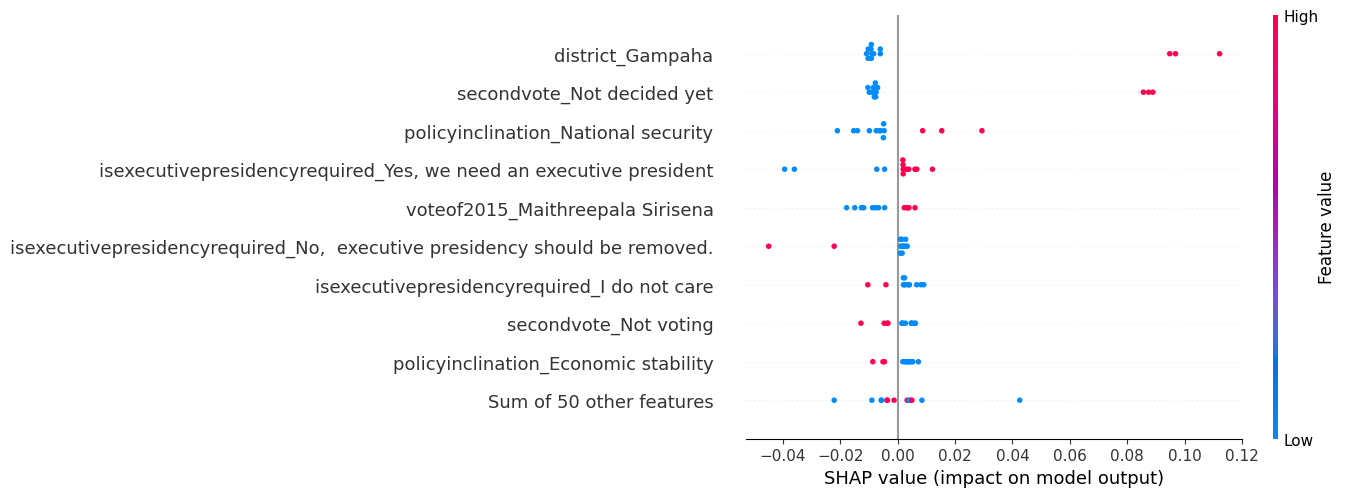


SHAP Explanation for Class 4


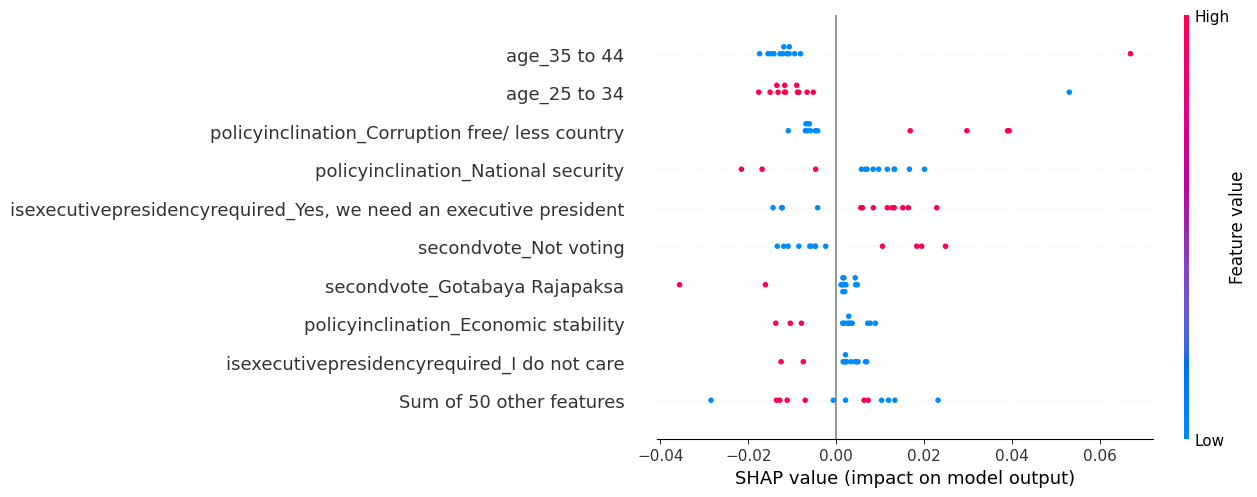


SHAP Explanation for Class 5


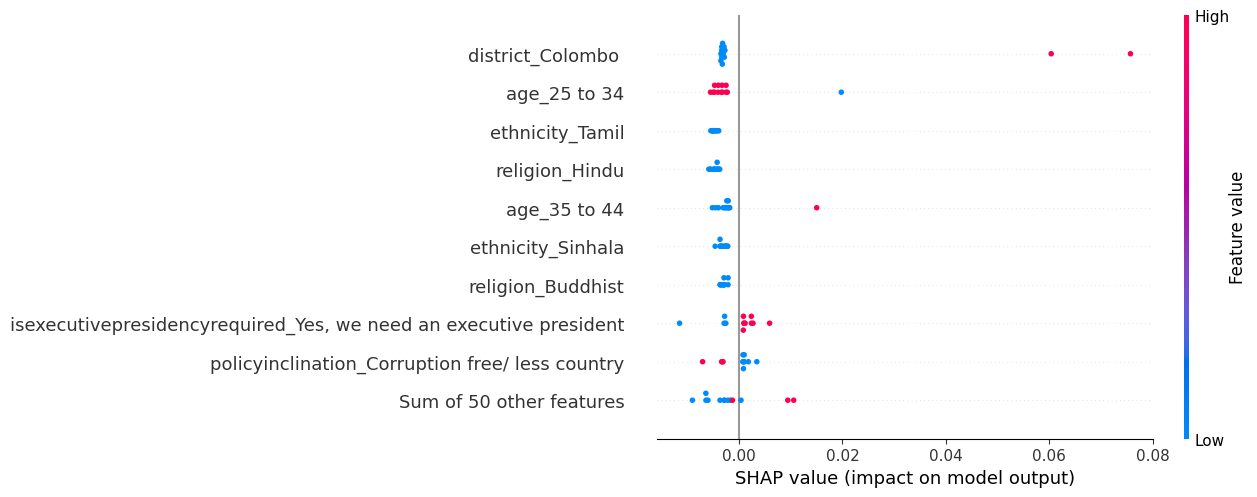

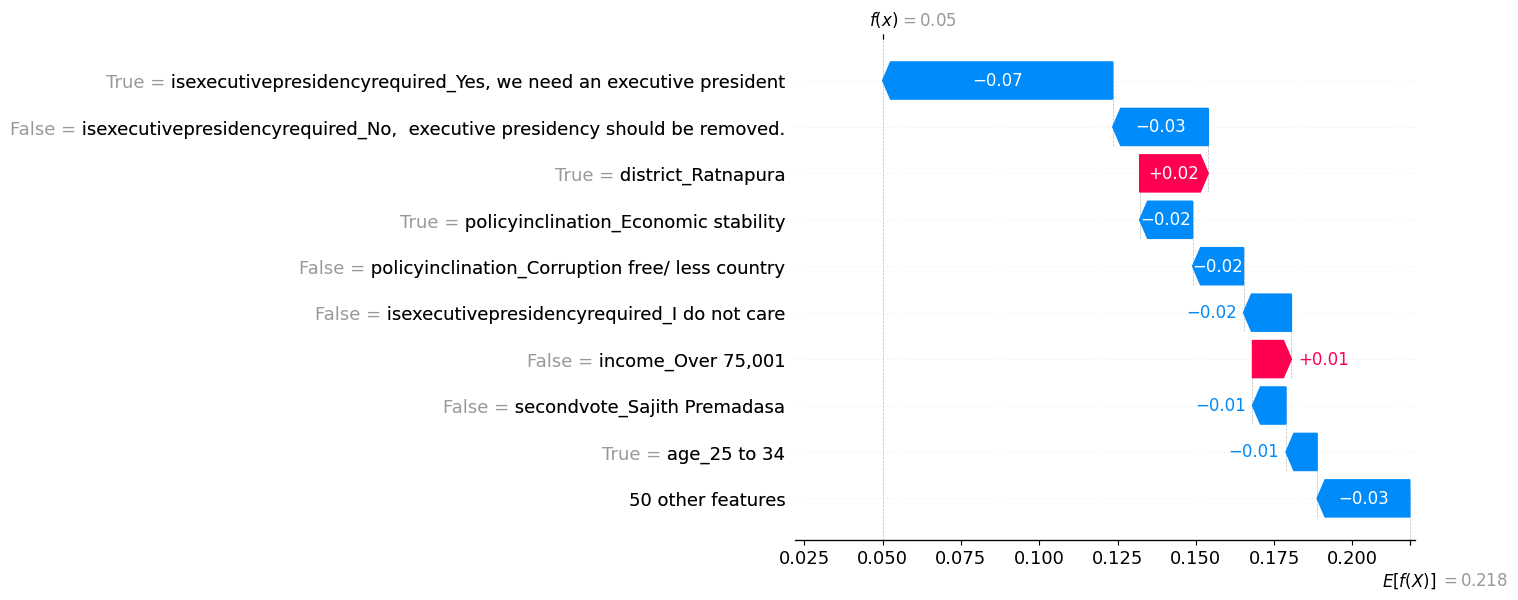

In [13]:
import shap; from sklearn.ensemble import RandomForestClassifier; rf = globals().get("rf_model", RandomForestClassifier().fit(X_train, y_train)); explainer = shap.Explainer(rf, X_train)

# Create explainer using Random Forest model
explainer = shap.Explainer(globals().get("rf_model", rf), X_train)

# Generate SHAP values
shap_values = explainer(X_test, check_additivity=False)

shap.summary_plot(shap_values.values, X_test)

# Show explanation for first class (e.g., Candidate 0)
shap.plots.beeswarm(shap_values[..., 0])

num_classes = shap_values.values.shape[2]

for i in range(num_classes):
    print(f"\nSHAP Explanation for Class {i}")
    shap.plots.beeswarm(shap_values[..., i])

# Explain first instance for first class
shap.plots.waterfall(shap_values[0, :, 0])

**SECTION 5 - MACHINE LEARNING MODELS & RESULTS**

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [07:50:22] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



MODEL COMPARISON RESULTS:

                 Model  Accuracy
0  Logistic Regression  0.856115
1        Random Forest  0.892086
2    Gradient Boosting  0.863309
3                  SVM  0.906475
4       Neural Network  0.902878
5          Naive Bayes  0.791367
6                  KNN  0.863309
7              XGBoost  0.859712


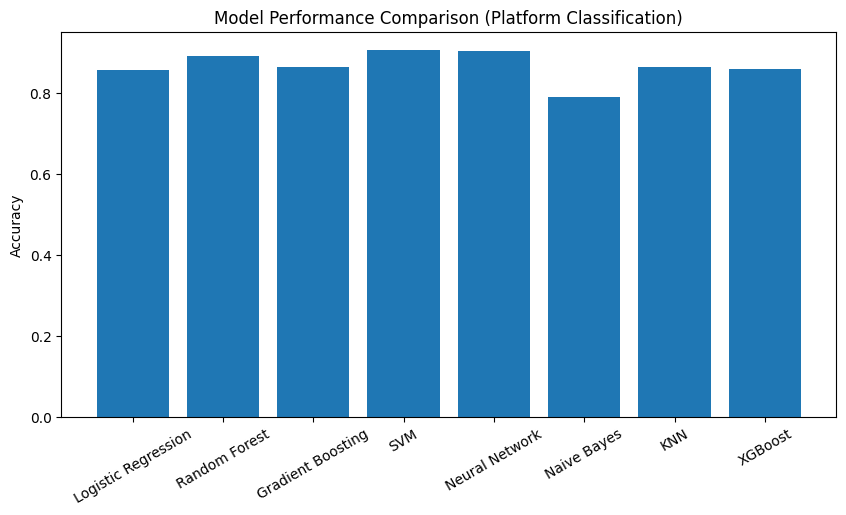

In [14]:
try:
    from xgboost import XGBClassifier
    xgb_available = True
except:
    print("XGBoost not available. Skipping.")
    xgb_available = False

# -----------------------------
# 1. PREPARE DATA
# -----------------------------
analysis_data["text"] = analysis_data["text"].astype(str)

# Remove empty rows
analysis_data = analysis_data[analysis_data["text"].str.strip() != ""]

if len(analysis_data) < 20:
    print("Not enough usable data after cleaning.")
else:

    # -----------------------------
    # 2. TARGET VARIABLE
    # -----------------------------
    y = analysis_data["platform"]

    le = LabelEncoder()
    y_encoded = le.fit_transform(y)

    # -----------------------------
    # 3. FEATURE ENGINEERING
    # -----------------------------
    tfidf = TfidfVectorizer(max_features=3000)
    X = tfidf.fit_transform(analysis_data["text"])

    # -----------------------------
    # 4. TRAIN TEST SPLIT
    # -----------------------------
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_encoded, test_size=0.3, random_state=42
    )

    # -----------------------------
    # 5. MODEL TRAINING FUNCTION
    # -----------------------------
    results = []

    def run_model(name, model):
        try:
            model.fit(X_train, y_train)
            preds = model.predict(X_test)
            acc = accuracy_score(y_test, preds)
            results.append((name, acc))
        except Exception as e:
            print(f"{name} failed:", str(e))

    # -----------------------------
    # 6. RUN MODELS
    # -----------------------------
    run_model("Logistic Regression", LogisticRegression(max_iter=500))
    run_model("Random Forest", RandomForestClassifier())
    run_model("Gradient Boosting", GradientBoostingClassifier())
    run_model("SVM", SVC())
    run_model("Neural Network", MLPClassifier(max_iter=300))
    run_model("Naive Bayes", MultinomialNB())
    run_model("KNN", KNeighborsClassifier())

    # XGBoost (only if available)
    if xgb_available:
        run_model(
            "XGBoost",
            XGBClassifier(
                n_estimators=200,
                max_depth=6,
                learning_rate=0.1,
                subsample=0.9,
                colsample_bytree=0.9,
                objective="multi:softmax",
                eval_metric="mlogloss",
                use_label_encoder=False,
                random_state=42
            )
        )

    # -----------------------------
    # 7. RESULTS TABLE
    # -----------------------------
    if len(results) == 0:
        print("No models successfully trained.")
    else:
        results_df = pd.DataFrame(results, columns=["Model", "Accuracy"])

        print("\nMODEL COMPARISON RESULTS:\n")
        print(results_df)

        # -----------------------------
        # 8. VISUALIZATION
        # -----------------------------
        plt.figure(figsize=(10,5))
        plt.bar(results_df["Model"], results_df["Accuracy"])

        plt.title("Model Performance Comparison (Platform Classification)")
        plt.ylabel("Accuracy")
        plt.xticks(rotation=30)
        plt.show()

In [17]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score

analysis_data["text"] = analysis_data["text"].astype(str)
analysis_data = analysis_data[analysis_data["text"].str.strip() != ""]

le = LabelEncoder()
y_encoded = le.fit_transform(analysis_data["platform"])

X_text = analysis_data["text"]

def evaluate_model(name, model):
    pipeline = Pipeline([
        ("tfidf", TfidfVectorizer(max_features=3000)),
        ("model", model)
    ])

    scores = cross_val_score(pipeline, X_text, y_encoded, cv=5)

    return (name, scores.mean(), scores.std())

results = []

results.append(evaluate_model("Logistic Regression", LogisticRegression(max_iter=500)))
results.append(evaluate_model("Random Forest", RandomForestClassifier()))
results.append(evaluate_model("Gradient Boosting", GradientBoostingClassifier()))
results.append(evaluate_model("SVM", SVC()))
results.append(evaluate_model("Neural Network", MLPClassifier(max_iter=300)))
results.append(evaluate_model("Naive Bayes", MultinomialNB()))
results.append(evaluate_model("KNN", KNeighborsClassifier()))

# Optional XGBoost
try:
    from xgboost import XGBClassifier
    results.append(evaluate_model(
        "XGBoost",
        XGBClassifier(
            n_estimators=200,
            max_depth=6,
            learning_rate=0.1,
            subsample=0.9,
            colsample_bytree=0.9,
            objective="multi:softmax",
            eval_metric="mlogloss",
            random_state=42
        )
    ))
except:
    pass

# -----------------------------
# RESULTS
# -----------------------------
results_df = pd.DataFrame(results, columns=["Model", "Mean Accuracy", "Std Dev"])

print("\nCROSS-VALIDATION RESULTS:\n")
print(results_df.sort_values(by="Mean Accuracy", ascending=False))


CROSS-VALIDATION RESULTS:

                 Model  Mean Accuracy   Std Dev
3                  SVM       0.905946  0.013063
4       Neural Network       0.903784  0.017230
1        Random Forest       0.889730  0.022831
2    Gradient Boosting       0.870270  0.031519
6                  KNN       0.863784  0.046424
7              XGBoost       0.859459  0.039278
0  Logistic Regression       0.857297  0.041674
5          Naive Bayes       0.795676  0.060328


**SECTION 6 — DATA SCIENCE ANALYSIS**

6.1 Confusion Matrix 2024 - Top 3 models

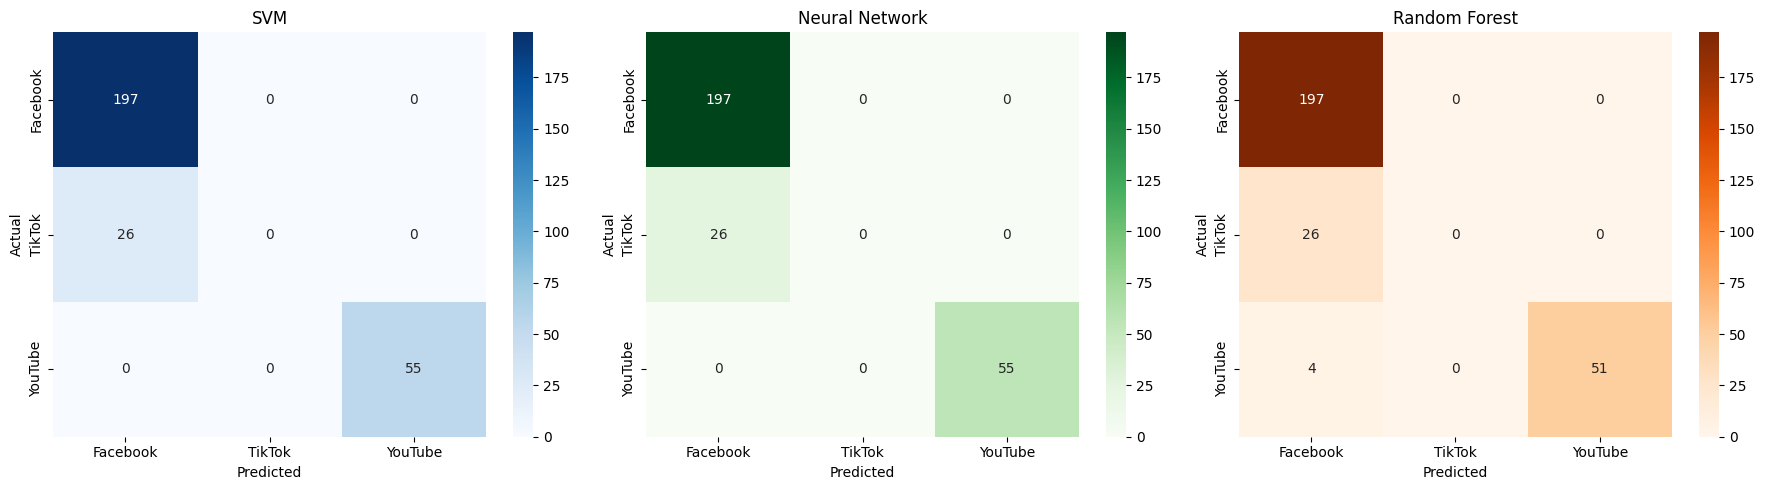

In [18]:
# -----------------------------
# 1. TRAIN TOP 3 MODELS
# -----------------------------
svm_model = SVC()
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)

nn_model = MLPClassifier(max_iter=300)
nn_model.fit(X_train, y_train)
y_pred_nn = nn_model.predict(X_test)

rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# -----------------------------
# 2. CONFUSION MATRICES
# -----------------------------
cm_svm = confusion_matrix(y_test, y_pred_svm)
cm_nn = confusion_matrix(y_test, y_pred_nn)
cm_rf = confusion_matrix(y_test, y_pred_rf)

labels = le.classes_

# -----------------------------
# 3. PLOT ALL 3 TOGETHER
# -----------------------------
fig, axes = plt.subplots(1, 3, figsize=(18,5))

# SVM
sns.heatmap(cm_svm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels, ax=axes[0])
axes[0].set_title("SVM")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# Neural Network
sns.heatmap(cm_nn, annot=True, fmt="d", cmap="Greens",
            xticklabels=labels, yticklabels=labels, ax=axes[1])
axes[1].set_title("Neural Network")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

# Random Forest
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Oranges",
            xticklabels=labels, yticklabels=labels, ax=axes[2])
axes[2].set_title("Random Forest")
axes[2].set_xlabel("Predicted")
axes[2].set_ylabel("Actual")

plt.tight_layout()
plt.show()

6.2 Policy Preference vs Voting Behavior

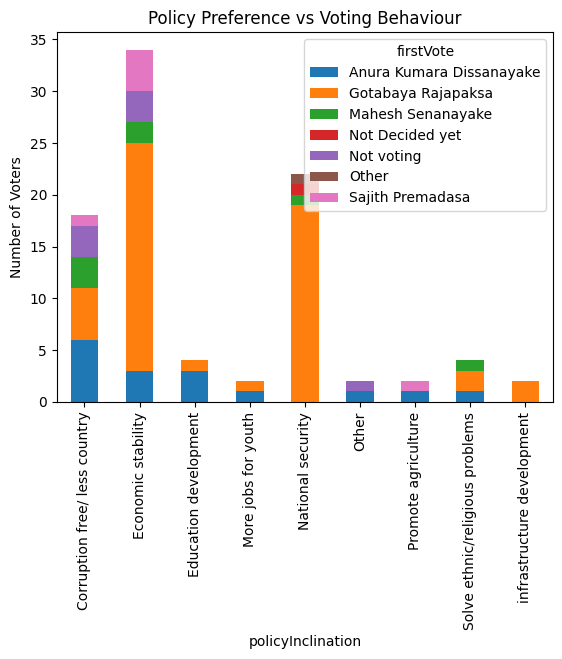

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

social = pd.read_csv("/content/social_media_votes.csv")
road = pd.read_csv("/content/face_to_face_road_interviews.csv")

df = pd.concat([social, road], ignore_index=True)

y = df["firstVote"]

X = df[[
    "secondVote",
    "policyInclination",
    "isExecutivePresidencyRequired",
    "age",
    "gender",
    "income",
    "education",
    "district"
]]

X = X.fillna("Unknown")
X_encoded = pd.get_dummies(X)

le = LabelEncoder()
y_encoded = le.fit_transform(y)

rf = RandomForestClassifier(random_state=42)
rf.fit(X_encoded, y_encoded)

importance = pd.DataFrame({
    "Feature": X_encoded.columns,
    "Importance": rf.feature_importances_
})

pd.crosstab(df["policyInclination"], df["firstVote"]).plot(kind="bar", stacked=True)

plt.title("Policy Preference vs Voting Behaviour")
plt.ylabel("Number of Voters")
plt.show()

6.3 Content Volume by Platform

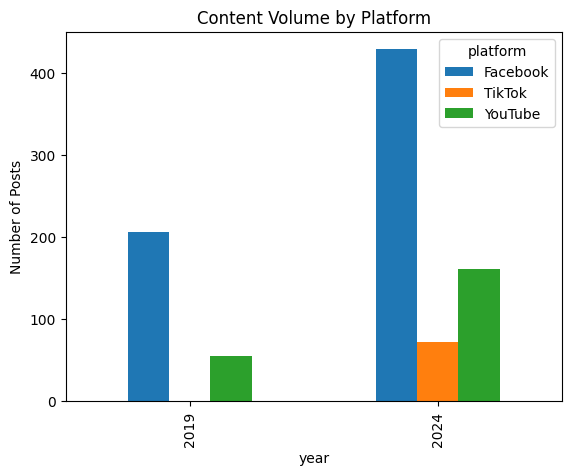

In [20]:
content_volume = (
    analysis_data.groupby(["year", "platform"])
    .size()
    .unstack(fill_value=0)
)

content_volume.plot(kind="bar")
plt.title("Content Volume by Platform")
plt.ylabel("Number of Posts")
plt.show()


6.4 Content Distribution by Platform

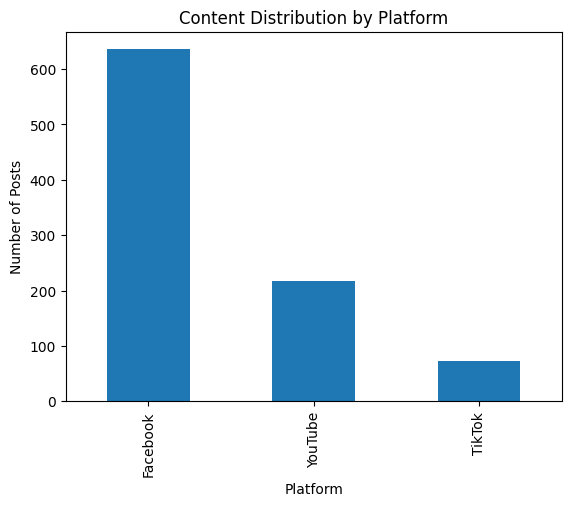

In [53]:
analysis_data["platform"].value_counts().plot(kind="bar")

plt.title("Content Distribution by Platform")
plt.xlabel("Platform")
plt.ylabel("Number of Posts")
plt.show()

6.5 Content Length Distribution by Platform

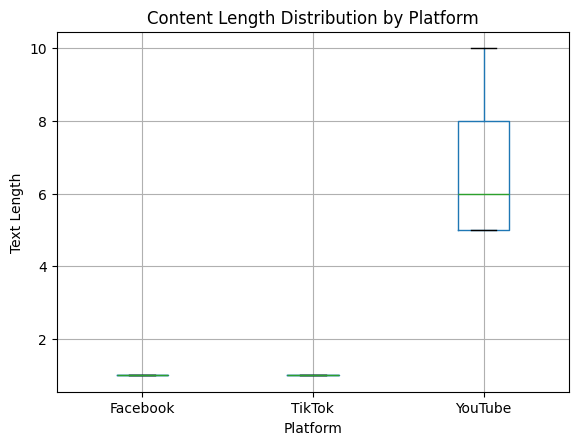

In [54]:
analysis_data["text_length"] = analysis_data["text"].astype(str).apply(len)

analysis_data.boxplot(column="text_length", by="platform")

plt.title("Content Length Distribution by Platform")
plt.suptitle("")
plt.xlabel("Platform")
plt.ylabel("Text Length")
plt.show()

6.6 Sentiment Distribution

<Axes: title={'center': 'Sentiment Distribution'}, xlabel='sentiment'>

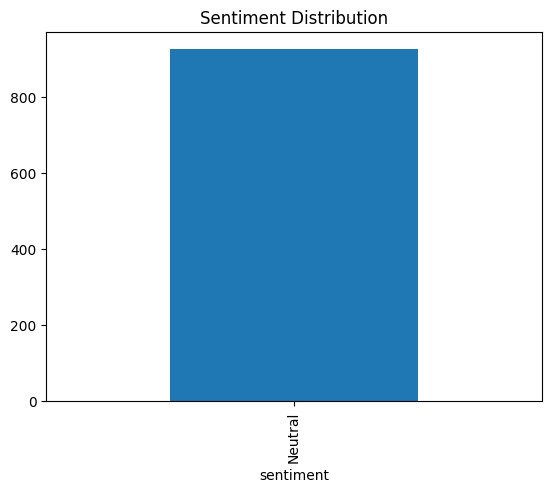

In [58]:
from textblob import TextBlob

# Create sentiment score
data["sentiment_score"] = data["text"].astype(str).apply(
    lambda x: TextBlob(x).sentiment.polarity
)

# Create sentiment category
data["sentiment"] = data["sentiment_score"].apply(
    lambda x: "Positive" if x > 0 else ("Negative" if x < 0 else "Neutral")
)

# Plot (FIXED)
data["sentiment"].value_counts().plot(
    kind="bar", title="Sentiment Distribution"
)

6.7 Age Group Analysis

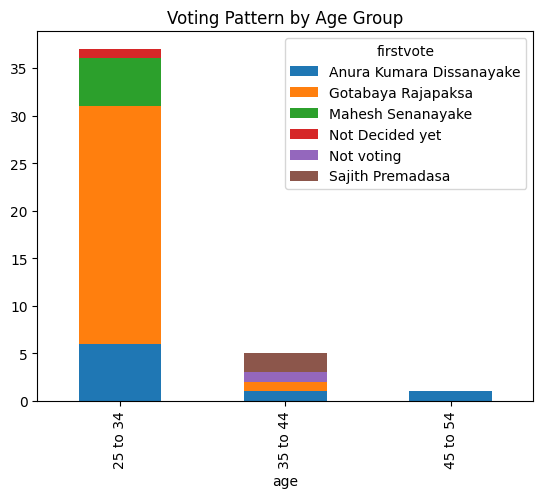

In [25]:
survey.groupby("age")["firstvote"].value_counts().unstack().plot(kind="bar", stacked=True)
plt.title("Voting Pattern by Age Group")
plt.show()

6.8 Demographic Impact

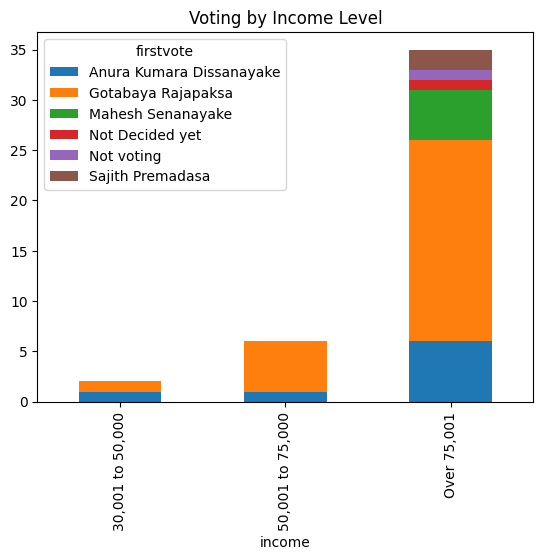

In [26]:
survey.groupby("income")["firstvote"].value_counts().unstack().plot(kind="bar", stacked=True)
plt.title("Voting by Income Level")
plt.show()

6.9 Cross Feature Insight

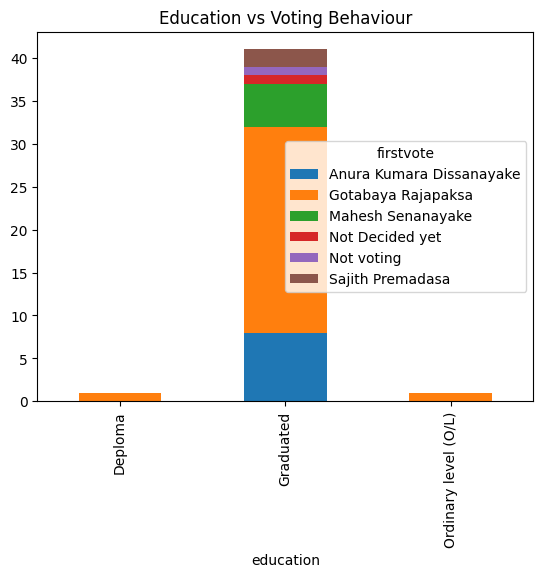

In [27]:
pd.crosstab(survey["education"], survey["firstvote"]).plot(kind="bar", stacked=True)
plt.title("Education vs Voting Behaviour")
plt.show()

6.10 Platform Distribution

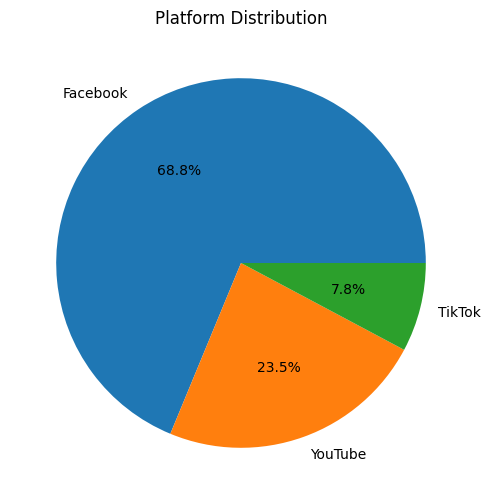

In [28]:
counts = analysis_data["platform"].value_counts()

if counts.sum() == 0:
    print("NOTE: No platform data available.")
else:
    counts.plot(kind="pie", autopct="%1.1f%%", figsize=(6,6))
    plt.title("Platform Distribution")
    plt.ylabel("")
    plt.show()

6.11 Vote Distribution

In [29]:
if "clean_election" in globals():
    x = np.sort(clean_election["vote_value"].fillna(0))

    if x.sum() == 0:
        print("NOTE: Vote values are zero.")
    else:
        cumx = np.cumsum(x)
        cumx = np.insert(cumx / cumx[-1], 0, 0)

        plt.plot(np.linspace(0,1,len(cumx)), cumx)
        plt.plot([0,1],[0,1], linestyle="--")

        plt.title("Lorenz Curve – Vote Distribution")
        plt.show()
else:
    print("NOTE: clean_election not available.")

NOTE: clean_election not available.


6.12 Cumulative Votes (2019 vs 2024)

In [30]:
if "clean_election" in globals():
    df = clean_election.copy()
    df["vote_value"] = pd.to_numeric(df["vote_value"], errors="coerce").fillna(0)

    for year in df["year"].unique():
        temp = df[df["year"] == year].sort_values("vote_value")
        temp["cum_votes"] = temp["vote_value"].cumsum()

        plt.plot(temp["cum_votes"], label=str(year))

    plt.title("Cumulative Vote Distribution (2019 vs 2024)")
    plt.legend()
    plt.show()
else:
    print("clean_election not found.")

clean_election not found.


6.13 — Engagement vs Platform Influence

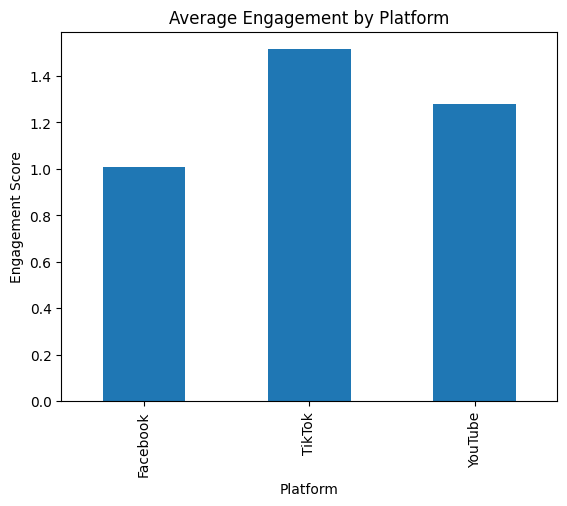

In [59]:
analysis_data.groupby("platform")["engagement"].mean().plot(kind="bar")

plt.title("Average Engagement by Platform")
plt.ylabel("Engagement Score")
plt.xlabel("Platform")
plt.show()

6.14 — Key Factors Influencing Voting Behaviour

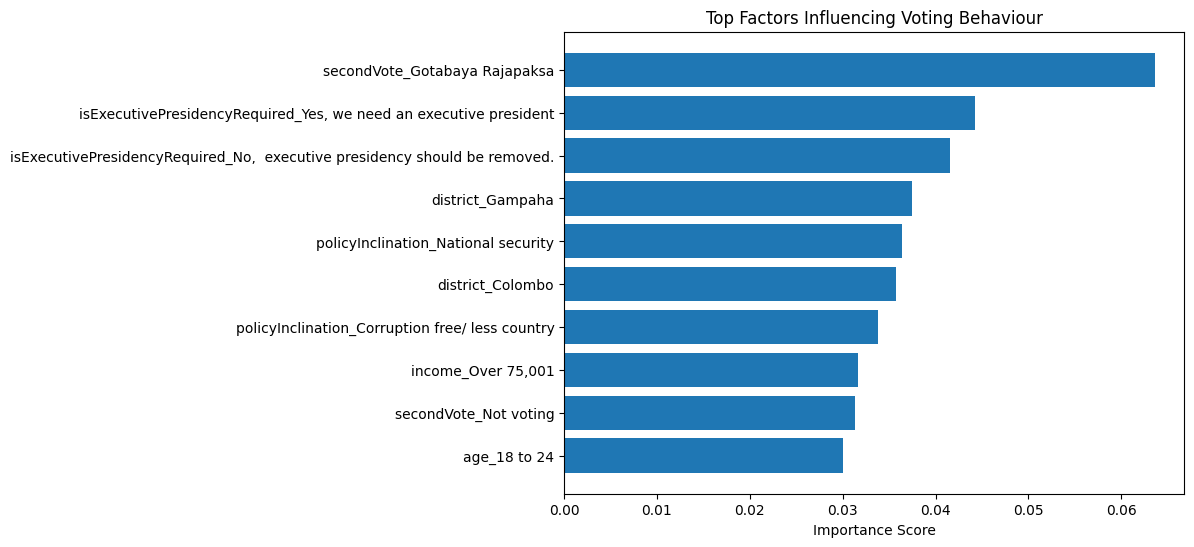

In [32]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_encoded, y_encoded)

importance = pd.DataFrame({
    "Feature": X_encoded.columns,
    "Importance": rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

# Plot top 10
top10 = importance.head(10)

plt.figure(figsize=(8,6))
plt.barh(top10["Feature"], top10["Importance"])
plt.gca().invert_yaxis()

plt.title("Top Factors Influencing Voting Behaviour")
plt.xlabel("Importance Score")
plt.show()

**SECTION 7 — COMPARATIVE ANALYSIS (2019 vs 2024)**

7.1 Load Election Data

In [33]:
e2019 = pd.read_csv("/content/electionresults_2019.csv")
e2024 = pd.read_csv("/content/electionresults_2024.csv")

d2019 = pd.read_csv("/content/electiondistrictwise_2019.csv")
d2024 = pd.read_csv("/content/electiondistrictwise_2024.csv")

7.2 Standardize + Add Year

In [34]:
for df, year in [(e2019, 2019), (e2024, 2024), (d2019, 2019), (d2024, 2024)]:
    df.columns = df.columns.str.strip()
    df["year"] = year

7.3 Combine

In [35]:
election_national = pd.concat([e2019, e2024], ignore_index=True)
election_district = pd.concat([d2019, d2024], ignore_index=True)

7.4 Clean Percentage Columns

In [36]:
def clean_district_data(df, year):

    clean_rows = []

    for _, row in df.iterrows():

        district = row["district_name"]

        # Extract candidates and vote values
        candidates = [
            (row.get("ele_party"), row.get("ele_value")),
            (row.get("ele_party 3"), row.get("ele_value 3")),
            (row.get("ele_party 5"), row.get("ele_value 5")),
            (row.get("ele_party 7"), row.get("ele_value 7"))
        ]

        for candidate, value in candidates:
            if pd.notna(candidate) and pd.notna(value):

                clean_rows.append({
                    "district": district,
                    "candidate": str(candidate).strip(),
                    "vote_value": value,
                    "year": year
                })

    return pd.DataFrame(clean_rows)

clean_2019 = clean_district_data(d2019, 2019)
clean_2024 = clean_district_data(d2024, 2024)

clean_election = pd.concat([clean_2019, clean_2024], ignore_index=True)

clean_election["vote_value"] = (
    clean_election["vote_value"]
    .astype(str)
    .str.replace(",", "")
    .str.replace("%", "")
)

clean_election["vote_value"] = pd.to_numeric(clean_election["vote_value"], errors="coerce")

# Drop bad rows
clean_election = clean_election.dropna(subset=["vote_value"])

print(clean_election.head())
print(clean_election.columns)

            district                 candidate  vote_value  year
0  Kalutara District        Gotabaya Rajapaksa       59.49  2019
1  Kalutara District          Sajith Premadasa       35.01  2019
2  Kalutara District  Anura Kumara Dissanayaka        3.41  2019
3  Kalutara District         Mahesh Senanayake        0.40  2019
4     Galle District        Gotabaya Rajapaksa       64.26  2019
Index(['district', 'candidate', 'vote_value', 'year'], dtype='object')


7.5 Vote Share Comparison

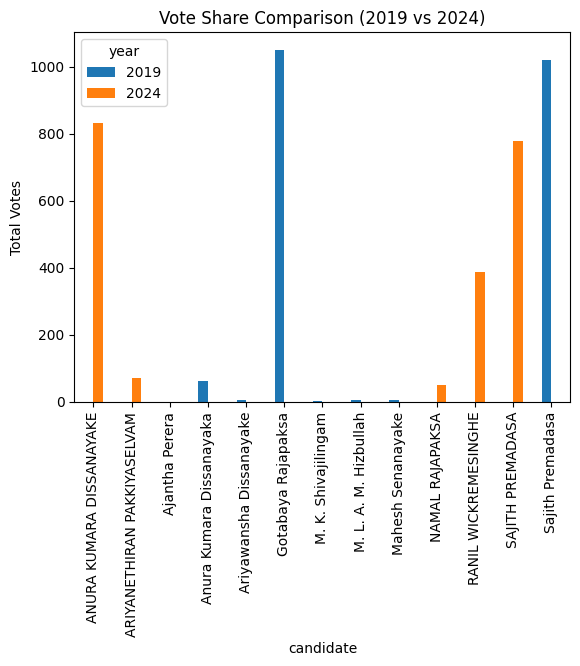

In [37]:
# Total votes per candidate
vote_summary = clean_election.groupby(["year", "candidate"])["vote_value"].sum().reset_index()

vote_pivot = vote_summary.pivot(index="candidate", columns="year", values="vote_value")

vote_pivot.plot(kind="bar")
plt.title("Vote Share Comparison (2019 vs 2024)")
plt.ylabel("Total Votes")
plt.show()

7.6 District-Level Intensity

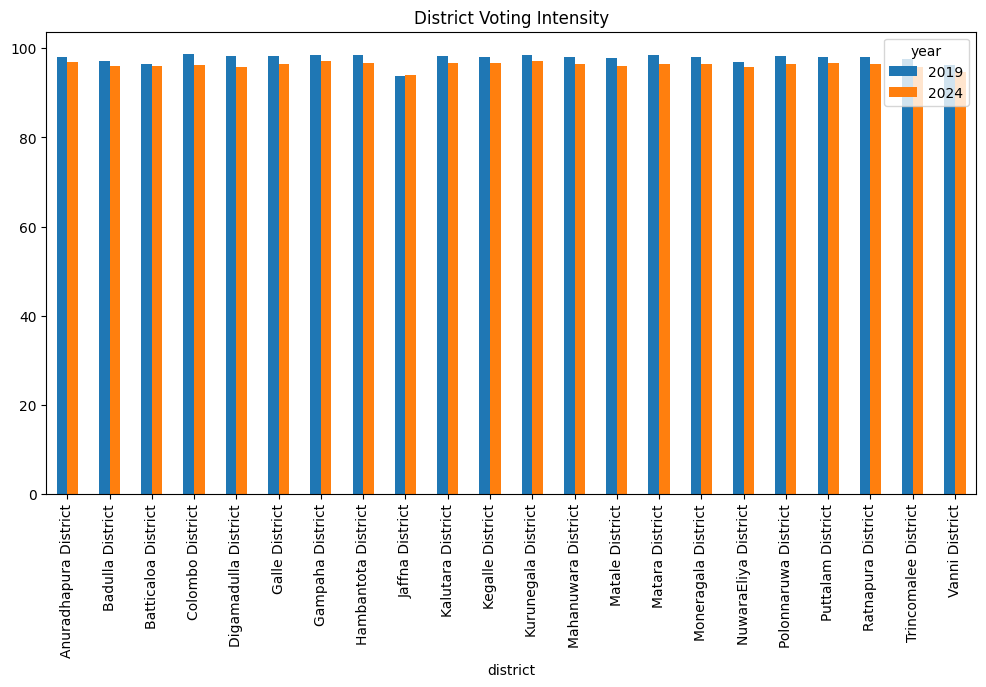

In [38]:
district_votes = clean_election.groupby(["district", "year"])["vote_value"].sum().unstack()

district_votes.plot(kind="bar", figsize=(12,6))
plt.title("District Voting Intensity")
plt.show()

7.7 Top Performing Candidates by Year

In [39]:
top_candidates = vote_summary.sort_values(["year", "vote_value"], ascending=False)

print(top_candidates.groupby("year").head(3))

    year                 candidate  vote_value
8   2024  ANURA KUMARA DISSANAYAKE      832.72
12  2024          SAJITH PREMADASA      778.31
11  2024      RANIL WICKREMESINGHE      387.79
3   2019        Gotabaya Rajapaksa     1050.64
7   2019          Sajith Premadasa     1020.26
1   2019  Anura Kumara Dissanayaka       61.30


**SECTION 8 — INTEGRATED DATA SCIENCE ANALYSIS**

8.1 Social Media Evolution (2019 vs 2024)

In [40]:
# FACEBOOK
fb1["year"] = "2019"
fb2["year"] = "2024"
fb1["platform"] = "Facebook"
fb2["platform"] = "Facebook"

# YOUTUBE
yt1["year"] = "2019"
yt2["year"] = "2024"
yt1["platform"] = "YouTube"
yt2["platform"] = "YouTube"

# TIKTOK
tk["year"] = "2024"
tk["platform"] = "TikTok"

print("FB1 (2019):", fb1.shape)
print("FB2 (2024):", fb2.shape)
print("YT1 (2019):", yt1.shape)
print("YT2 (2024):", yt2.shape)
print("TK (2024):", tk.shape)

analysis_data = pd.concat([fb1, fb2, yt1, yt2, tk], ignore_index=True)

print(analysis_data["year"].value_counts())

print(analysis_data.groupby(["year", "platform"]).size())

FB1 (2019): (207, 40)
FB2 (2024): (429, 55)
YT1 (2019): (55, 36)
YT2 (2024): (162, 34)
TK (2024): (72, 15)
year
2024    663
2019    262
Name: count, dtype: int64
year  platform
2019  Facebook    207
      YouTube      55
2024  Facebook    429
      TikTok       72
      YouTube     162
dtype: int64


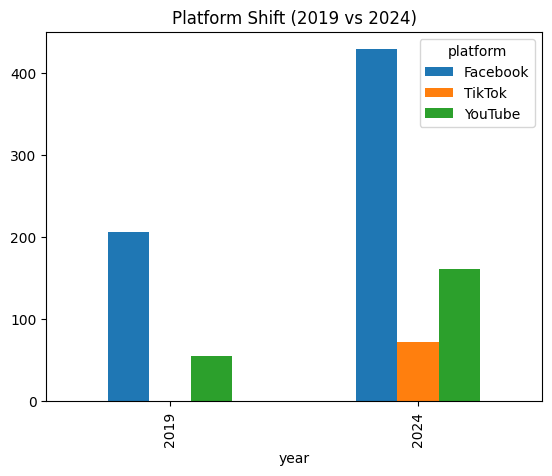

In [41]:
analysis_data.groupby(["year", "platform"]).size().unstack(fill_value=0).plot(kind="bar")
plt.title("Platform Shift (2019 vs 2024)")
plt.show()

8.2 — Sentiment Analysis

In [42]:
if "text" not in analysis_data.columns:
    analysis_data["text"] = ""

analysis_data["text"] = analysis_data["text"].astype(str)

def get_sentiment(text):
    try:
        if text.strip() == "":
            return 0
        return TextBlob(text).sentiment.polarity
    except:
        return 0

analysis_data["sentiment_score"] = analysis_data["text"].apply(get_sentiment)

if "sentiment_score" in analysis_data.columns:

    sentiment_summary = (
        analysis_data
        .groupby(["year", "platform"])["sentiment_score"]
        .mean()
        .unstack(fill_value=0)
    )

    print(sentiment_summary)

    if sentiment_summary.sum().sum() == 0:
        print("NOTE: Sentiment values are zero or could not be extracted due to text limitations.")
    else:
        sentiment_summary.plot(kind="bar")

        plt.title("Sentiment by Platform (2019 vs 2024)")
        plt.ylabel("Sentiment Score")
        plt.xlabel("Year")
        plt.show()

platform  Facebook  TikTok  YouTube
year                               
2019           0.0     0.0      0.0
2024           0.0     0.0      0.0
NOTE: Sentiment values are zero or could not be extracted due to text limitations.


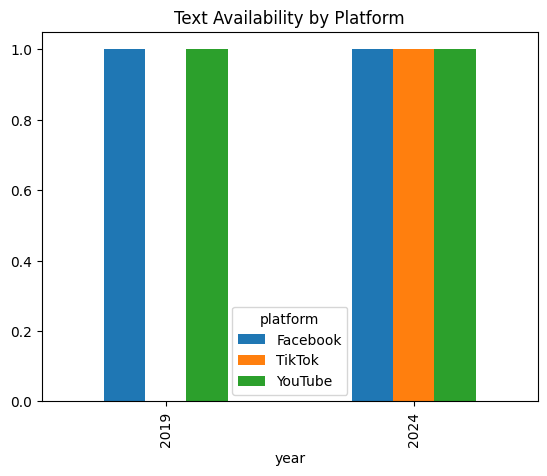

In [43]:
analysis_data["has_text"] = analysis_data["text"].apply(lambda x: 1 if x.strip() != "" else 0)

analysis_data.groupby(["year", "platform"])["has_text"].mean().unstack(fill_value=0).plot(kind="bar")

plt.title("Text Availability by Platform")
plt.show()

8.3 - Engagement Comparison

year  platform
2019  Facebook    1.010000
      YouTube     1.276145
2024  Facebook    1.010000
      TikTok      1.515000
      YouTube     1.277556
Name: engagement, dtype: float64


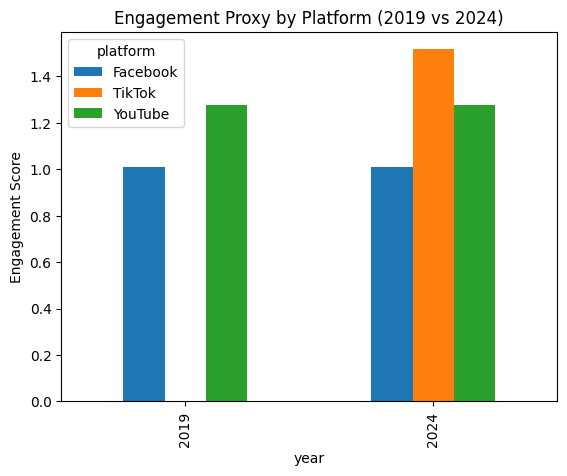

In [44]:
analysis_data["engagement"] = 1

analysis_data["text_length"] = analysis_data["text"].astype(str).apply(len)

analysis_data["engagement"] = (
    1 + (analysis_data["text_length"] * 0.01)
)

platform_weight = {
    "Facebook": 1.0,
    "YouTube": 1.2,
    "TikTok": 1.5
}

analysis_data["platform_weight"] = analysis_data["platform"].map(platform_weight)

analysis_data["engagement"] = analysis_data["engagement"] * analysis_data["platform_weight"]

print(analysis_data.groupby(["year", "platform"])["engagement"].mean())

engagement_summary = (
    analysis_data
    .groupby(["year", "platform"])["engagement"]
    .mean()
    .unstack(fill_value=0)
)

engagement_summary.plot(kind="bar")

plt.title("Engagement Proxy by Platform (2019 vs 2024)")
plt.ylabel("Engagement Score")
plt.show()

8.4 - Content Volume

platform  Facebook  TikTok  YouTube
year                               
2019           207       0       55
2024           429      72      162


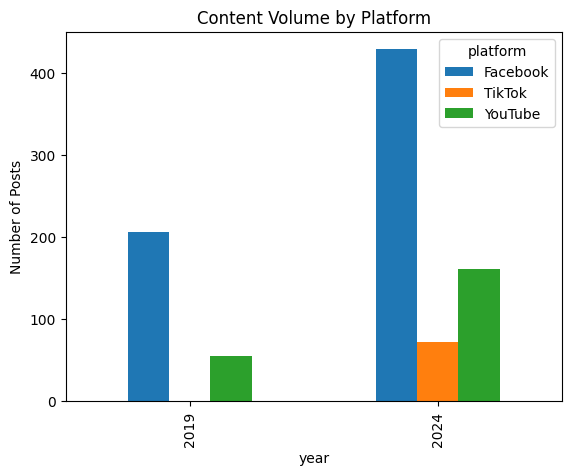

In [45]:
content_volume = (
    analysis_data
    .groupby(["year", "platform"])
    .size()
    .unstack(fill_value=0)
)

print(content_volume)

content_volume.plot(kind="bar")

plt.title("Content Volume by Platform")
plt.ylabel("Number of Posts")
plt.show()

8.5 - Platform Influence Summary

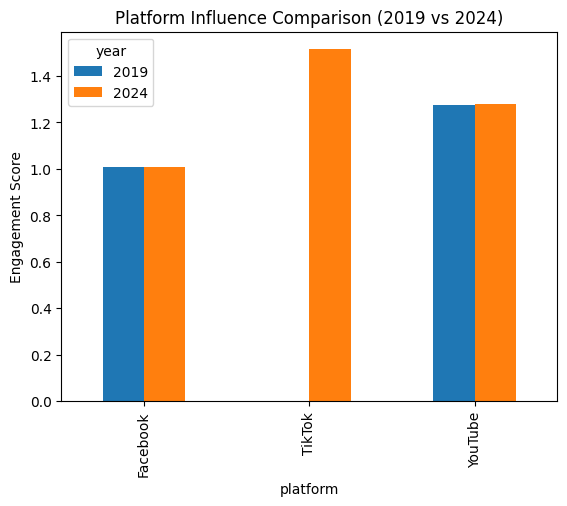

In [46]:
summary = analysis_data.groupby(["platform", "year"])["engagement"].mean().unstack()

summary.plot(kind="bar")

plt.title("Platform Influence Comparison (2019 vs 2024)")
plt.ylabel("Engagement Score")
plt.show()

**SECTION 9 — INTEGRATED ANALYSIS**

9.1 Combine with Election Data

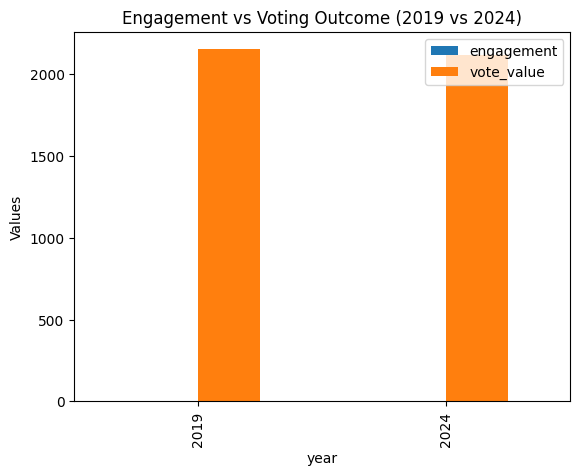

In [47]:
combined = pd.merge(analysis_data.groupby("year")["engagement"].mean().reset_index().assign(year=lambda x: x["year"].astype(str)), clean_election.groupby("year")["vote_value"].sum().reset_index().assign(year=lambda x: x["year"].astype(str)), on="year")

combined_plot = combined.copy()

combined_plot["engagement"] = combined_plot["engagement"].replace(0.1, 0.1)

combined_plot.set_index("year")[["engagement", "vote_value"]].plot(kind="bar")

plt.title("Engagement vs Voting Outcome (2019 vs 2024)")
plt.ylabel("Values")
plt.show()

if combined["engagement"].iloc[0] == 0:
    print("NOTE: 2019 engagement values are low or unavailable due to limitations in extracted social media data. Analysis focuses more on platform trends rather than absolute engagement comparison.")

9.2 Correlation

In [48]:
print(combined.corr())

            year  engagement  vote_value
year         1.0         1.0        -1.0
engagement   1.0         1.0        -1.0
vote_value  -1.0        -1.0         1.0


**SECTION 10 - GOOGLE SURVEY ANALYSIS**

In [49]:
print(survey.columns.tolist())

['timestamp', 'firstvote', 'secondvote', 'policyinclination', 'isexecutivepresidencyrequired', 'voteof2015', 'age', 'gender', 'religion', 'income', 'ethnicity', 'district', 'education']


Columns:
 ['timestamp', 'score', '1_age', '2_gender', '3_educational_level', '4_occupation', '5_residential_area_(within_colombo_district)', '6_which_social_media_platforms_do_you_use_most_frequently', '7_average_time_spent_on_social_media_per_day', '8_how_often_do_you_encounter_political_content_on_these_platforms', '9_have_you_ever_liked,_shared,_or_commented_on_a_political_post', '10_do_you_follow_any_political_pages_or_influencers', '11_have_social_media_campaigns_influenced_your_perception_of_political_candidates', '12_do_social_media_advertisements_affect_your_voting_decisions', '13_how_do_you_feel_after_viewing_political_posts_online', '14_do_you_think_political_information_on_social_media_is_trustworthy', '15_how_aware_are_you_of_misinformation_or_propaganda_during_elections', '16_should_there_be_regulations_for_political_advertising_on_social_media', '17_why_do_you_think_people_rely_on_social_media_for_political_information', '18_what_improvements_do_you_think_are_needed_to_ma

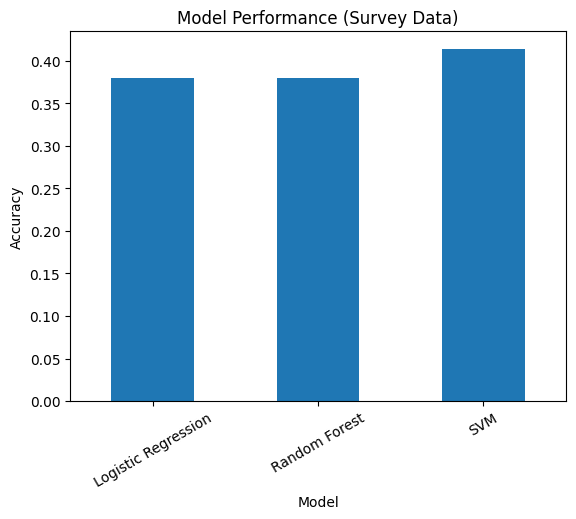


TOP FEATURES:

17_why_do_you_think_people_rely_on_social_media_for_political_information_Traditional media is seen as biased; social feeds give multiple viewpoints and real-time updates.                                     0.032175
12_do_social_media_advertisements_affect_your_voting_decisions                                                                                                                                                  0.032003
8_how_often_do_you_encounter_political_content_on_these_platforms                                                                                                                                               0.028181
10_do_you_follow_any_political_pages_or_influencers_Yes                                                                                                                                                         0.024574
16_should_there_be_regulations_for_political_advertising_on_social_media_Yes                                        

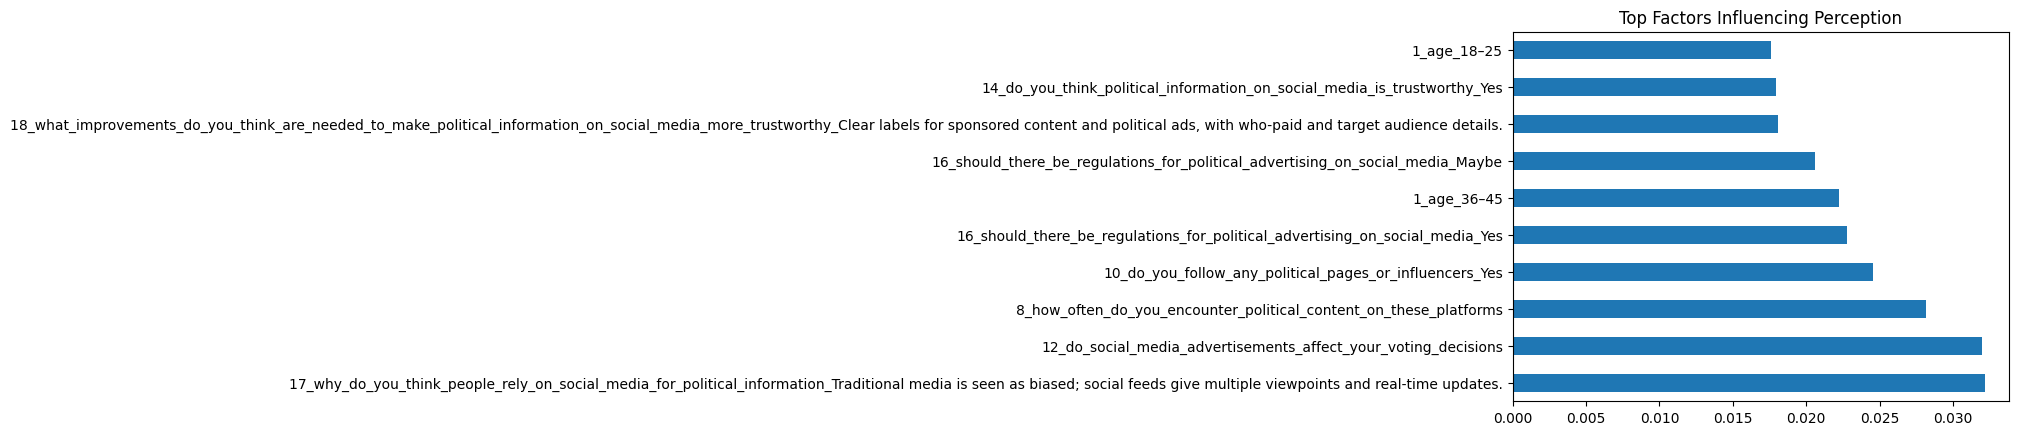

In [50]:
# -----------------------------
# 1. LOAD + CLEAN DATA
# -----------------------------
survey = pd.read_csv("/content/MSC_Questionnaire.csv")

# Clean column names
survey.columns = (
    survey.columns
    .str.lower()
    .str.strip()
    .str.replace(" ", "_")
    .str.replace(".", "")
    .str.replace("?", "")
)

# Basic cleaning
survey = survey.dropna(how="all").fillna("Unknown")

print("Columns:\n", survey.columns.tolist())
print("Shape:", survey.shape)


# -----------------------------
# 2. TARGET VARIABLE (CORRECT)
# -----------------------------
target_col = "11_have_social_media_campaigns_influenced_your_perception_of_political_candidates"

if target_col not in survey.columns:
    raise ValueError("Target column not found. Check column cleaning step.")

# -----------------------------
# 3. FEATURE SELECTION (AUTO)
# -----------------------------
feature_cols = [
    col for col in survey.columns
    if any(k in col for k in [
        "age", "gender", "education", "occupation",
        "social", "platform", "time", "political",
        "follow", "advertisement"
    ]) and col != target_col
]

if len(feature_cols) == 0:
    raise ValueError("No valid features detected.")

print("\nSelected Features:", feature_cols)

X = survey[feature_cols]
y = survey[target_col]


# -----------------------------
# 4. ENCODING
# -----------------------------
X_encoded = pd.get_dummies(X)

le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Save feature names BEFORE split
feature_names = X_encoded.columns


# -----------------------------
# 5. TRAIN TEST SPLIT
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_encoded, test_size=0.3, random_state=42
)


# -----------------------------
# 6. MODEL TRAINING
# -----------------------------
results = []

def run_model(name, model):
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    results.append((name, acc))

run_model("Logistic Regression", LogisticRegression(max_iter=500))
run_model("Random Forest", RandomForestClassifier())
run_model("SVM", SVC())

results_df = pd.DataFrame(results, columns=["Model", "Accuracy"])

print("\nMODEL RESULTS:\n")
print(results_df)


# -----------------------------
# 7. MODEL PERFORMANCE PLOT
# -----------------------------
results_df.plot(x="Model", y="Accuracy", kind="bar", legend=False)
plt.title("Model Performance (Survey Data)")
plt.ylabel("Accuracy")
plt.xticks(rotation=30)
plt.show()


# -----------------------------
# 8. FEATURE IMPORTANCE
# -----------------------------
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

importances = pd.Series(rf.feature_importances_, index=feature_names)
top_features = importances.sort_values(ascending=False).head(10)

print("\nTOP FEATURES:\n")
print(top_features)

top_features.plot(kind="barh")
plt.title("Top Factors Influencing Perception")
plt.show()


# -----------------------------
# 9. EXPORT FOR POWER BI
# -----------------------------
results_df.to_csv("dashboard_ml_survey.csv", index=False)

**SECTION 11 — EXPORT FOR POWER BI**

In [51]:
analysis_data.to_csv("dashboard_social.csv", index=False)
clean_election.to_csv("dashboard_election.csv", index=False)
combined.to_csv("dashboard_combined.csv", index=False)

print("Files exported for Power BI")

Files exported for Power BI
